## EEG


In [12]:
import re
import math
import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import ast
%matplotlib inline

In [14]:
def parse_num_list(value):
    if pd.isna(value):
        return None
    text = str(value).strip()
    if not text:
        return None
    if text[0] == "[" and text[-1] == "]":
        text = text[1:-1]
    arr = np.fromstring(text, sep=",", dtype=np.float32)
    if arr.size == 0:
        return None
    return arr


def fix_len(arr, n):
    if arr is None:
        return None
    if arr.size == n:
        return arr.astype(np.float32)
    if arr.size > n:
        return arr[:n].astype(np.float32)
    out = np.zeros(n, dtype=np.float32)
    out[: arr.size] = arr
    return out


def power_to_seq(power, n=512):
    if power is None:
        return None
    power = fix_len(power, 8)
    x_old = np.arange(8, dtype=np.float32)
    x_new = np.linspace(0, 7, n, dtype=np.float32)
    return np.interp(x_new, x_old, power).astype(np.float32)

LABELS_JSON_PATH = Path("labels.json")
if not LABELS_JSON_PATH.exists():
    raise FileNotFoundError(f"Missing label mapping file: {LABELS_JSON_PATH}")

_RAW_LABEL_MAP = json.loads(LABELS_JSON_PATH.read_text(encoding="utf-8"))
LABELS = 9
if LABELS == 9:
    # Map to 9 major classes.
    _RAW_LABEL_MAP = _RAW_LABEL_MAP.get("labels_9", {})
elif LABELS == 19:
    # Map to 19 classes (mostly 1-to-1 with raw labels).
    _RAW_LABEL_MAP = _RAW_LABEL_MAP.get("labels_19", {})
else:
    raise ValueError(f"Unsupported number of labels: {LABELS}")

def _resolve_label_once(src: str, label_map: dict, cache: dict) -> str:
    if src in cache:
        return cache[src]

    seen = set()
    cur = src
    while cur in label_map and cur not in seen:
        seen.add(cur)
        cur = label_map[cur]

    cache[src] = cur
    return cur


# Flatten any chained mappings exactly once for O(1) runtime lookup.
_RESOLVED_LABEL_MAP = {}
for _key in _RAW_LABEL_MAP:
    _resolve_label_once(_key, _RAW_LABEL_MAP, _RESOLVED_LABEL_MAP)

# Optional case-insensitive support.
_RESOLVED_LABEL_MAP_LOWER = {k.lower(): v for k, v in _RESOLVED_LABEL_MAP.items()}


def to_major_class(label: str) -> str:
    s = str(label).strip()
    if not s:
        return s

    mapped = _RESOLVED_LABEL_MAP.get(s)
    if mapped is not None:
        return mapped

    mapped = _RESOLVED_LABEL_MAP_LOWER.get(s.lower())
    if mapped is not None:
        return mapped

    # Fast fallback for unseen labels.
    base = re.split(r"[-_]", s)[0]
    base = re.sub(r"\d+$", "", base)
    return base or s

In [ ]:
RAW_PATH = Path("EEG/eeg-data.csv")
eeg_data = pd.read_csv(RAW_PATH, converters={"eeg_power": parse_num_list, "raw_values": parse_num_list})
original_size = eeg_data.shape[0]
print(f"Original size of the dataset: {original_size}")
eeg_data = eeg_data[eeg_data.label != 'unlabeled']
print(f"Size of the dataset after removing unlabeled data: {eeg_data.shape[0]}")
eeg_data = eeg_data[eeg_data['signal_quality'] <= 128].copy()
print(f"Data loss percentage: {(1 - eeg_data.shape[0] / original_size) * 100:.2f}%")
eeg_data = eeg_data[['id', 'eeg_power', 'raw_values', 'label']]
print("Data shape after dropping unnecessary columns:", eeg_data.shape)
print("Columns:", eeg_data.columns)

# def extract_eeg_lists(eeg_power_str): # Runs faster thatn ast.literal_eval() and eval()
#     return [float(n) for n in eeg_power_str.split("[")[1].split("]")[0].split(",")]
# eeg_data.eeg_power = eeg_data.eeg_power.apply(extract_eeg_lists)
# eeg_data.raw_values = eeg_data.raw_values.apply(extract_eeg_lists)


Original size of the dataset: 30013
Size of the dataset after removing unlabeled data: 9959
Data loss percentage: 66.83%
Data shape after dropping unnecessary columns: (9954, 4)
Columns: Index(['id', 'eeg_power', 'raw_values', 'label'], dtype='object')


In [21]:
print(f"Number of IDs: {len(list(eeg_data.id.value_counts().keys()))}")
print(f"Number of labels: {len(list(eeg_data.label.value_counts().keys()))}")

Number of IDs: 30
Number of labels: 67


# Labels


In [22]:
eeg_data['label'] = eeg_data['label'].map(to_major_class)
eeg_data.reset_index(inplace=True)
print(f"Data shape after collating minor classes into major ones: {eeg_data.shape}")
print(f"Unique classes after collating minor classes into major ones: \t{len(eeg_data['label'].unique())}")

Data shape after collating minor classes into major ones: (9954, 5)
Unique classes after collating minor classes into major ones: 	9


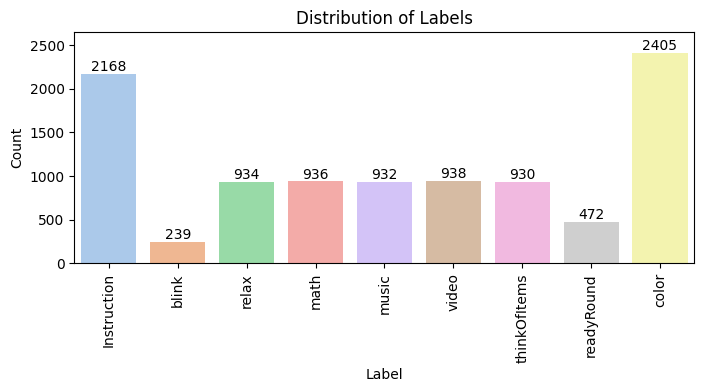

In [26]:
plt.figure(figsize=(8, 3))
sns.countplot(x='label', data=eeg_data, palette='pastel', hue='label')
for label in eeg_data.label.value_counts().keys():
    count = eeg_data[eeg_data.label == label].shape[0]
    plt.text(label, count, str(count), ha='center', va='bottom', rotation=0)
plt.title('Distribution of Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.ylim(0, max(eeg_data['label'].value_counts()) * 1.1)
plt.show()

In [32]:
def summarize_vector(values, prefix):
    arr = np.asarray(values, dtype=float)
    if arr.size == 0:
        return {
            f"{prefix}_len": 0.0,
            f"{prefix}_mean": np.nan,
            f"{prefix}_std": np.nan,
            f"{prefix}_min": np.nan,
            f"{prefix}_max": np.nan,
            f"{prefix}_median": np.nan,
            f"{prefix}_q05": np.nan,
            f"{prefix}_q95": np.nan,
            f"{prefix}_abs_mean": np.nan,
            f"{prefix}_clip_ratio": np.nan,
        }

    return {
        f"{prefix}_len": float(arr.size),
        f"{prefix}_mean": float(arr.mean()),
        f"{prefix}_std": float(arr.std()),
        f"{prefix}_min": float(arr.min()),
        f"{prefix}_max": float(arr.max()),
        f"{prefix}_median": float(np.median(arr)),
        f"{prefix}_q05": float(np.quantile(arr, 0.05)),
        f"{prefix}_q95": float(np.quantile(arr, 0.95)),
        f"{prefix}_abs_mean": float(np.mean(np.abs(arr))),
        f"{prefix}_clip_ratio": float(np.mean(np.abs(arr) >= 2047.0)),
    }

# Sample power and raw values


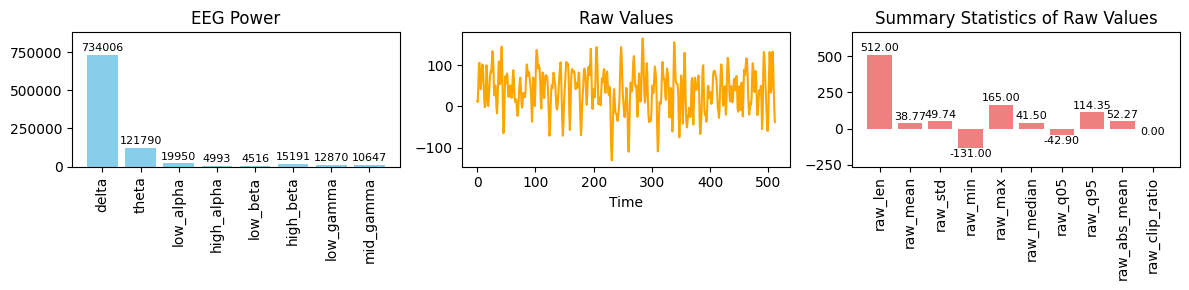

In [41]:
random_index = np.random.choice(eeg_data.index)
POWER_BANDS = ['delta', 'theta', 'low_alpha', 'high_alpha', 'low_beta', 'high_beta', 'low_gamma', 'mid_gamma']
fig, axs = plt.subplots(1, 3, figsize=(12, 3))

axs[0].bar(POWER_BANDS, eeg_data.eeg_power[random_index], color='skyblue')
for p in axs[0].patches:
    axs[0].annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=8, color='black', xytext=(0, 5),
                    textcoords='offset points')
axs[0].set_title('EEG Power')
axs[0].set_ylim(0, max(eeg_data.eeg_power[random_index]) * 1.2)
axs[0].set_xticks(range(len(POWER_BANDS)))
axs[0].set_xticklabels(POWER_BANDS, rotation=90)

axs[1].plot(eeg_data.raw_values[random_index], label='Raw Values', color='orange')
axs[1].set_title('Raw Values')
axs[1].set_xlabel('Time')

raw_features = summarize_vector(eeg_data.raw_values[random_index], 'raw')
axs[2].bar(raw_features.keys(), raw_features.values(), color='lightcoral')
for i, value in enumerate(raw_features.values()):
    axs[2].text(i, value + math.copysign(10, value),
                f'{value:.2f}', ha='center', va='bottom' if value > 0 else 'top', fontsize=8)
axs[2].set_title('Summary Statistics of Raw Values')
axs[2].set_xticks(range(len(raw_features.keys())))
axs[2].set_xticklabels(raw_features.keys(), rotation=90)
axs[2].set_ylim(min(raw_features.values()) * 2, max(raw_features.values()) * 1.3)

plt.tight_layout()
plt.show()


### To further preprocess the data, all these raw value stats could be considered as additional features (new columns).

### Then, train/val/test split for some initial model development and evaluation.

### Class (label) balance is very important, also subject leakage!

### More advanced models (CNN, RNN, Transformer) could be also developed without these features.
